# EDA Analysis 

Data understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
customers = pd.read_csv("customers_cleaned.csv")
products = pd.read_csv("products_cleaned.csv")
orders = pd.read_csv("orders_cleaned.csv")
inventory = pd.read_csv("inventory_cleaned.csv")

In [30]:
customers.shape

(300, 6)

In [31]:
customers.head(3)

,customer_id,customer_name,city,customer_segment,customer_since,state
0,C0001,Customer_0001,Chennai,Online,2023-03-21,Tamil Nadu
1,C0002,Customer_0002,Bengaluru,Retailer,2024-05-25,Karnataka
2,C0003,Customer_0003,Hyderabad,Retailer,2025-04-20,Telangana


In [32]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   customer_id       300 non-null    str  
 1   customer_name     300 non-null    str  
 2   city              300 non-null    str  
 3   customer_segment  300 non-null    str  
 4   customer_since    300 non-null    str  
 5   state             300 non-null    str  
dtypes: str(6)
memory usage: 14.2 KB


In [33]:
customers['customer_since'] = pd.to_datetime(customers['customer_since'])
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customer_id       300 non-null    str           
 1   customer_name     300 non-null    str           
 2   city              300 non-null    str           
 3   customer_segment  300 non-null    str           
 4   customer_since    300 non-null    datetime64[us]
 5   state             300 non-null    str           
dtypes: datetime64[us](1), str(5)
memory usage: 14.2 KB


univatiate analysis:

In [34]:
customers.head(3)

,customer_id,customer_name,city,customer_segment,customer_since,state
0,C0001,Customer_0001,Chennai,Online,2023-03-21,Tamil Nadu
1,C0002,Customer_0002,Bengaluru,Retailer,2024-05-25,Karnataka
2,C0003,Customer_0003,Hyderabad,Retailer,2025-04-20,Telangana


1. customer segementation distribution

In [35]:
customers['customer_segment'].value_counts()

customer_segment
Retailer       101
Supermarket     96
Wholesaler      55
Online          48
Name: count, dtype: int64

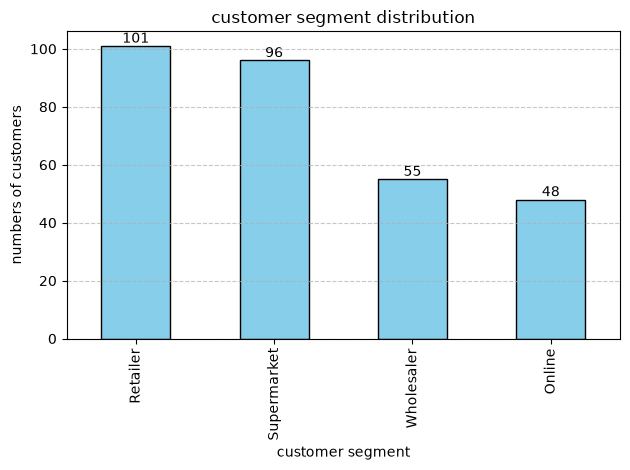

In [3]:
ax = customers['customer_segment'].value_counts().plot(
    kind='bar' , color='skyblue', edgecolor='black')
plt.title("customer segment distribution")
plt.xlabel("customer segment")
plt.ylabel("numbers of customers")
plt.bar_label(ax.containers[0])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

insight : Retailers and Supermarkets dominate the customer base, together forming the majority of segments. Wholesalers contribute moderately, while Online customers are the smallest group. This suggests the business is more dependent on offline channels, with scope to expand Online presence.

2.Which cities have the highest number of customers?

In [37]:
customers["city"].value_counts()

city
Bengaluru    46
Chennai      43
Mumbai       40
Ahmedabad    35
Hyderabad    34
Delhi        34
Pune         34
Kolkata      34
Name: count, dtype: int64

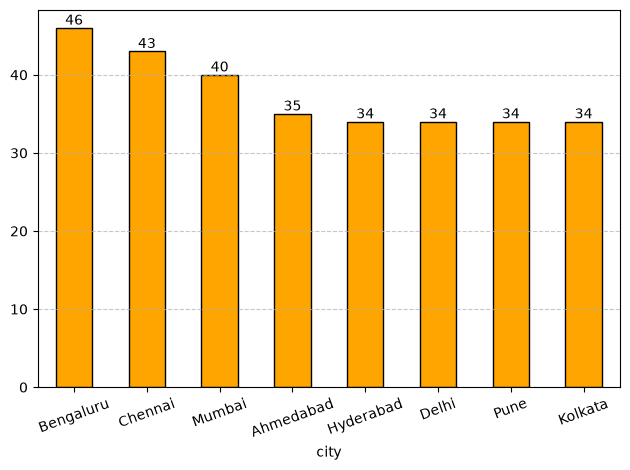

In [4]:
ax= customers["city"].value_counts().plot(
    kind="bar" ,color='orange', edgecolor='black')
plt.xticks(rotation=20)
plt.bar_label(ax.containers[0])
plt.grid(axis='y', linestyle='--',alpha=0.7)
plt.tight_layout()
plt.show()

insights : Bengaluru, Chennai, and Mumbai are the top three cities, showing the strongest customer presence.Ahmedabad, Hyderabad, Delhi, Pune, and Kolkata have similar mid‑level counts (~34–35), indicating balanced distribution.Overall, the customer base is spread across major metros, but Bengaluru leads slightly.

Products :

3. Which product categories have the largest product portfolio?

In [83]:
products["category"].value_counts()

category
Household        11
Beverages        11
Snacks           10
Personal Care    10
Packaged Food     8
Name: count, dtype: int64

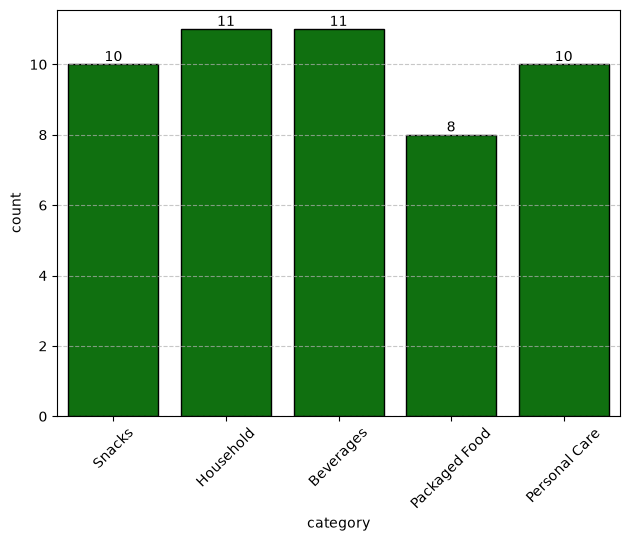

In [5]:
ax = sns.countplot(
    data=products, x="category", color='green',edgecolor='black')
plt.bar_label(ax.containers[0])
plt.grid(axis='y' ,linestyle='--', alpha=0.7)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

insights : Household & Beverages → 11 products each (largest categories). Snacks & Personal Care → 10 products each (mid‑range). Packaged Food → 8 products (smallest category). This suggests Household and Beverages drive assortment strength, whereas Packaged Food may need expansion to balance category mix.

4. How are product selling prices distributed?

In [39]:
products.head(3)

,product_id,product_name,category,unit_cost,selling_price
0,P001,Product_001,Snacks,143.99,236.14
1,P002,Product_002,Household,352.03,497.59
2,P003,Product_003,Beverages,104.49,143.80


In [40]:
products['selling_price'].describe()

count     50.000000
mean     334.056000
std      186.130669
min       64.060000
25%      177.792500
50%      299.760000
75%      479.220000
max      729.320000
Name: selling_price, dtype: float64

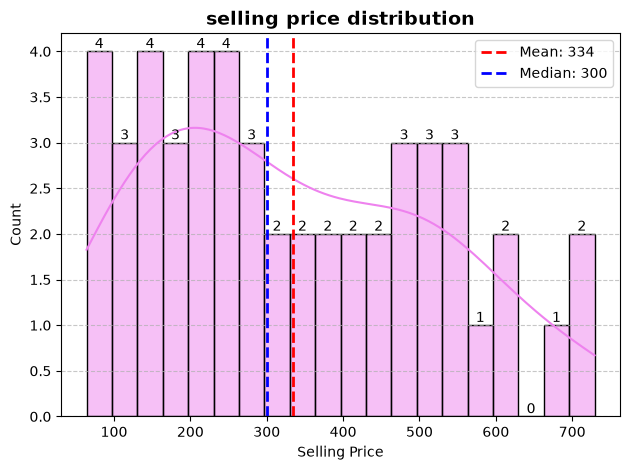

In [9]:
ax =sns.histplot(
    products['selling_price'],
    kde=True, bins=20, color='violet',edgecolor='black')
plt.bar_label(ax.containers[0])

#add mean and median line:
mean_val = products['selling_price'].mean()
median_val =products['selling_price'].median()

plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.0f}')
plt.axvline(median_val, color='blue', linestyle='--', linewidth=2, label=f'Median: {median_val:.0f}')

#title and labels:
plt.title("selling price distribution", fontsize=14, fontweight='bold')
plt.xlabel("Selling Price")
plt.ylabel("Count")

#grids and legends:
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

insights : The histogram shows most products priced at the lower range (₹100–₹300), with counts steadily declining as prices increase. Very few products are priced above ₹600, indicating a skew towards affordable items. This suggests the portfolio is concentrated in low‑to‑mid price bands, catering primarily to cost‑sensitive customers.

5. orders analysis :

In [42]:
orders.head(3)

,order_id,customer_id,product_id,order_date,quantity,discount_pct,sales_amount,cost_amount,profit,order_status,month,month_name,year
0,O00001,C0200,P013,2025-08-05,11,0.10,3463.52,2524.28,939.24,Delivered,8,August,2025
1,O00002,C0023,P040,2025-01-26,2,0.05,206.47,168.80,37.67,Delivered,1,January,2025
2,O00003,C0218,P008,2025-10-30,7,0.05,632.88,516.67,116.21,Delivered,10,October,2025


In [43]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   order_id      2000 non-null   str    
 1   customer_id   2000 non-null   str    
 2   product_id    2000 non-null   str    
 3   order_date    2000 non-null   str    
 4   quantity      2000 non-null   int64  
 5   discount_pct  1999 non-null   float64
 6   sales_amount  2000 non-null   float64
 7   cost_amount   2000 non-null   float64
 8   profit        2000 non-null   float64
 9   order_status  2000 non-null   str    
 10  month         2000 non-null   int64  
 11  month_name    2000 non-null   str    
 12  year          2000 non-null   int64  
dtypes: float64(4), int64(3), str(6)
memory usage: 203.3 KB


In [44]:
orders["sales_amount"].describe()

count     2000.000000
mean      2376.797595
std       2029.469086
min         54.450000
25%        816.422500
50%       1707.340000
75%       3449.185000
max      10939.800000
Name: sales_amount, dtype: float64

6. Is the company mostly generating profit, or are loss-making orders significant?

In [45]:
orders['profit'].describe()

count    2000.000000
mean      600.099405
std       668.500012
min      -297.380000
25%       134.270000
50%       360.755000
75%       848.755000
max      4412.700000
Name: profit, dtype: float64

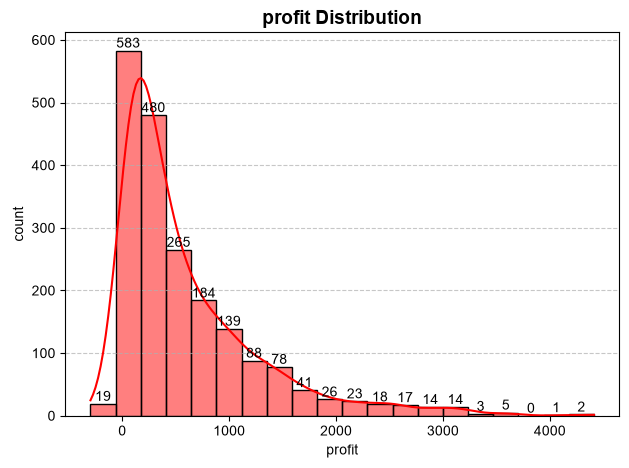

In [14]:
ax= sns.histplot(
    orders['profit'], 
    kde=True, bins=20, color='red', edgecolor='black')

plt.bar_label(ax.containers[0])

#titles and labels :
plt.title("profit Distribution", fontsize=14, fontweight='bold' )
plt.xlabel("profit")
plt.ylabel("count")

plt.grid(axis='y', linestyle='--', alpha= 0.7 )
plt.tight_layout()
sns.set_style("whitegrid")
plt.show()

In [47]:
(orders['profit'] <0).sum()

np.int64(51)

In [48]:
(orders['profit'] <0).mean()*100

np.float64(2.55)

insight : Out of 2000 orders, only 51 (2.54%) resulted in losses. This indicates that the business is largely profitable, but further analysis is needed to identify which categories or regions are driving these losses.

7. orders quantity distribution:

In [49]:
orders['quantity'].describe()

count    2000.000000
mean        7.861500
std         4.302973
min         1.000000
25%         4.000000
50%         8.000000
75%        12.000000
max        15.000000
Name: quantity, dtype: float64

In [50]:
orders['quantity'].median()

np.float64(8.0)

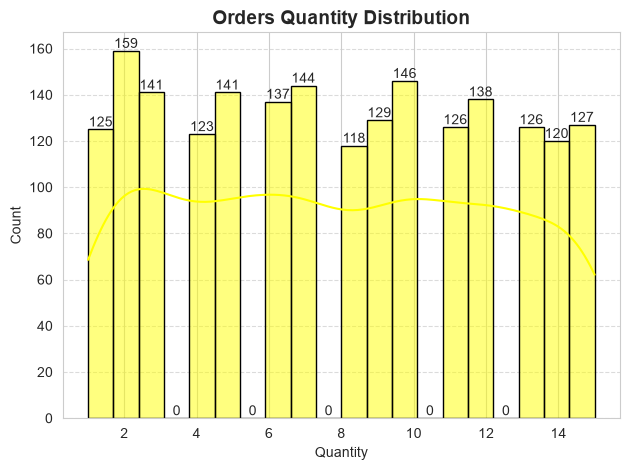

In [16]:
ax= sns.histplot(
    orders['quantity'],
    bins=20, color='yellow', edgecolor='black', kde=True,)

#title and bar labels :
plt.bar_label(ax.containers[0])
plt.xlabel("Quantity")
plt.ylabel("Count")
plt.title("Orders Quantity Distribution", fontsize=14, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

insights :Order quantities are fairly evenly distributed between 1 and 15 units, with the average order size around 8 units. This suggests customers typically purchase in mid-range quantities, so inventory and packaging strategies should focus on 8–10 unit bundles.

In [52]:
orders.head()

,order_id,customer_id,product_id,order_date,quantity,discount_pct,sales_amount,cost_amount,profit,order_status,month,month_name,year
0,O00001,C0200,P013,2025-08-05,11,0.10,3463.52,2524.28,939.24,Delivered,8,August,2025
1,O00002,C0023,P040,2025-01-26,2,0.05,206.47,168.80,37.67,Delivered,1,January,2025
2,O00003,C0218,P008,2025-10-30,7,0.05,632.88,516.67,116.21,Delivered,10,October,2025
3,O00004,C0141,P005,2025-01-05,8,0.10,1972.08,1646.48,325.60,Delivered,1,January,2025
4,O00005,C0104,P009,2025-01-20,1,0.15,408.64,284.51,124.13,Delivered,1,January,2025


In [53]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   order_id      2000 non-null   str    
 1   customer_id   2000 non-null   str    
 2   product_id    2000 non-null   str    
 3   order_date    2000 non-null   str    
 4   quantity      2000 non-null   int64  
 5   discount_pct  1999 non-null   float64
 6   sales_amount  2000 non-null   float64
 7   cost_amount   2000 non-null   float64
 8   profit        2000 non-null   float64
 9   order_status  2000 non-null   str    
 10  month         2000 non-null   int64  
 11  month_name    2000 non-null   str    
 12  year          2000 non-null   int64  
dtypes: float64(4), int64(3), str(6)
memory usage: 203.3 KB


In [54]:
orders['order_date'] =pd.to_datetime(orders['order_date'])

In [55]:
orders['month'] = orders['order_date'].dt.to_period("M")

8. How does revenue change month by month?

In [19]:
monthly_sales = orders.groupby('month')['sales_amount'].sum()
monthly_sales

month
1     436576.11
2     299464.22
3     410960.75
4     446182.90
5     367378.08
6     384682.63
7     404849.81
8     384681.18
9     397286.32
10    434026.83
11    428813.99
12    358692.37
Name: sales_amount, dtype: float64

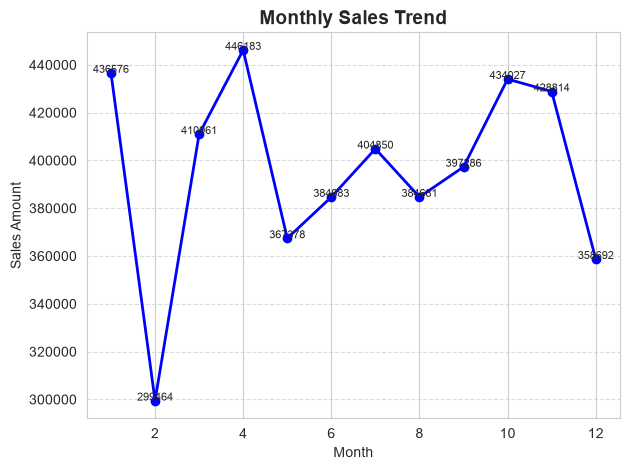

In [20]:
ax = monthly_sales.plot(
    kind='line', 
    marker='o',         
    color='blue', 
    linewidth=2
)

# Title & labels
plt.title("Monthly Sales Trend", fontsize=14, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Sales Amount")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate values on points
for x, y in zip(monthly_sales.index, monthly_sales.values):
    plt.text(x, y+50, f'{y:.0f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()


insights : sales growth is highest peak shown in month of april , then the second month in which growth is up which is oct and then jul , the profit in the month of feb is very less

9. top 10 products by revenue:

In [58]:
top_10_products =orders.groupby("product_id")["sales_amount"].sum()
top_10_products.sort_values(ascending=False)
top_10_products.head(10)

product_id
P001     71668.48
P002    135468.85
P003     38826.00
P004     64411.03
P005     63709.14
P006     82351.47
P007     28795.92
P008     32210.30
P009    142061.59
P010     63238.28
Name: sales_amount, dtype: float64

insights: Top 10 products contribute majorly to revenue, with P009 and P002 being clear leaders. These two products alone account for a significant share, so focusing marketing, inventory, and promotions around them could maximize sales impact. Meanwhile, products like P003 and P007 show weaker performance and may need strategy adjustments

10. top 10 products by profit 

In [59]:
top_10_pro_byprof =orders.groupby("product_id")["profit"].sum()
top_10_pro_byprof.sort_values(ascending=False)
top_10_pro_byprof.head(10)

product_id
P001    22711.88
P002    31267.97
P003     6852.06
P004    14017.43
P005    10610.16
P006    25057.73
P007     7288.56
P008     4974.41
P009    49595.84
P010    13473.49
Name: profit, dtype: float64

11. category revenue

In [60]:
sales_product = orders.merge(products ,on="product_id", how="inner")
sales_product.groupby("category")["sales_amount"].sum()

category
Beverages        1089745.71
Household         882838.30
Packaged Food     772310.23
Personal Care     966132.30
Snacks           1042568.65
Name: sales_amount, dtype: float64

insights : beverages is the top highest revenue generated category 

12. category profitability

In [61]:
sales_product.groupby("category")["profit"].sum()

category
Beverages        281938.67
Household        219589.19
Packaged Food    209945.35
Personal Care    203392.66
Snacks           285332.94
Name: profit, dtype: float64

insights : snacks is the most profitable category among all of the categories

In [62]:
category_analysis = sales_product.groupby("category").agg(
    revenue =("sales_amount","sum") ,
    profit= ("profit","sum")
)
category_analysis["profit_margin"] = (
    category_analysis["profit"]/
    category_analysis["revenue"] *100
)
category_analysis

,revenue,profit,profit_margin
category,,,
Beverages,1089745.71,281938.67,25.871969
Household,882838.30,219589.19,24.873093
Packaged Food,772310.23,209945.35,27.184070
Personal Care,966132.30,203392.66,21.052258
Snacks,1042568.65,285332.94,27.368264


insights : Snacks and Packaged Food deliver the highest profit margins (~27%), making them the most profitable categories per unit of sales. Beverages and Household generate strong revenues but slightly lower margins (~25%). Personal Care, despite high revenue, has the lowest margin (~21%), indicating potential cost or pricing issues. Focusing on margin optimization in Personal Care and scaling high-margin categories like Snacks could maximize overall profitability.

#### Q13. Does discount affect profit?

In [63]:
orders[["discount_pct", "profit"]].corr()

,discount_pct,profit
discount_pct,1.000000,-0.279904
profit,-0.279904,1.000000


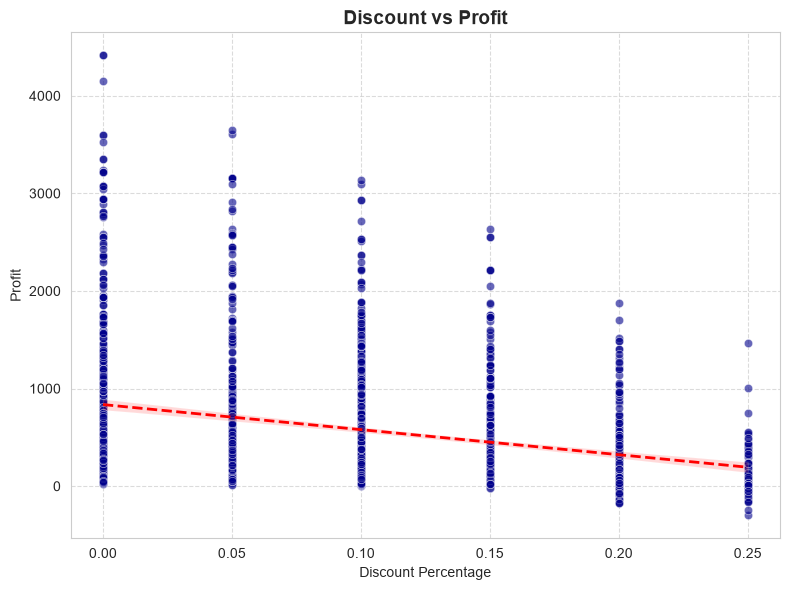

In [21]:
plt.figure(figsize=(8,6))
ax = sns.scatterplot(
    data=orders,
    x="discount_pct",
    y="profit",
    color="darkblue",
    alpha=0.6,         
    edgecolor="white"
)
sns.regplot(
    data=orders,
    x="discount_pct",
    y="profit",
    scatter=False,
    color="red",
    line_kws={"linewidth":2, "linestyle":"--"}
)
# Titles and labels
plt.title("Discount vs Profit", fontsize=14, fontweight='bold')
plt.xlabel("Discount Percentage")
plt.ylabel("Profit")

# Gridlines
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

insights: There is a weak negative correlation (-0.28) between discount percentage and profit, suggesting that higher discounts tend to reduce profitability. Regression line → shows overall negative trend (discount ↑ → profit ↓).



In [65]:
orders.groupby("discount_pct")["profit"].mean()

discount_pct
0.00    810.865442
0.05    748.091391
0.10    593.671107
0.15    445.882830
0.20    304.432464
0.25    174.307692
Name: profit, dtype: float64

insight : This indicates that aggressive discounting erodes profitability, and the business should cap discounts around 10–15% to balance sales growth with margin protection.

14. Which customer segment generates the most revenue?

which customers segments generate the most revenue ?

In [66]:
customer_orders = orders.merge(
    customers,
    on= "customer_id",
    how="left"
)
customer_orders.groupby("customer_segment") ["sales_amount"].sum()

customer_segment
Online          701427.68
Retailer       1544010.01
Supermarket    1583838.37
Wholesaler      924319.13
Name: sales_amount, dtype: float64

insights : supermaket customer segment have the highest sales .

15. which segment is most profitable ?

In [67]:
customer_orders.groupby("customer_segment")["profit"].sum()

customer_segment
Online         183455.28
Retailer       386558.56
Supermarket    396868.18
Wholesaler     233316.79
Name: profit, dtype: float64

insights : the supermarket is the highest generated profit segment with the profit amount ~3,86,558 

16. Which customer segment has the highest average order value?

In [68]:
aov = orders["sales_amount"].sum() / orders["order_id"].nunique()
aov

np.float64(2376.797595)

In [69]:
segment_aov = customer_orders.groupby(
    "customer_segment"
).agg(
    revenue = ("sales_amount", "sum"),
    orders = ("order_id" , "nunique")
)

segment_aov["AOV"] =(
    segment_aov["revenue"]/
    segment_aov["orders"]
)
segment_aov

,revenue,orders,AOV
customer_segment,,,
Online,701427.68,286,2452.544336
Retailer,1544010.01,661,2335.869909
Supermarket,1583838.37,680,2329.174074
Wholesaler,924319.13,373,2478.067373


insights : Wholesaler has the highest AOV (~₹2478), meaning each order generates more value compared to other segments. Online customers also show strong AOV (~₹2453) but with fewer orders, indicating untapped growth potential. Retailer and Supermarket drive the largest revenues through volume, but their AOV is slightly lower (~₹2336), suggesting scope for upselling or bundling to lift per‑order value.

17. Which products contribute most to total losses?

In [70]:
loss_orders = orders[orders["profit"] <0]

In [71]:
loss_orders.groupby("product_id")["profit"].sum().sort_values()

product_id
P034   -1107.15
P028    -746.95
P014    -400.22
P024    -268.66
P039    -243.90
P036     -96.44
P026     -69.48
P046     -66.96
P018     -46.24
P040     -17.38
P005      -5.39
P008      -4.86
Name: profit, dtype: float64

insights : P034, P028, P014, P024, P039 this products generates most loss out of all the products 

18. Are losses concentrated in certain categories?

In [72]:
loss_analysis = loss_orders.merge(
    products,
    on= "product_id",
    how= "left"
)

loss_analysis.groupby("category")["profit"].sum()

category
Household        -648.98
Packaged Food    -752.34
Personal Care   -1386.27
Snacks           -286.04
Name: profit, dtype: float64

personel care : biggest loss (-1386) hight cost or pricing issue 

packages food and household : moderate losses (-752 , -649)

snacks : smallest loss (-286), still negative but less servere

19. Fast-moving vs slow-moving products

In [81]:
fast_moving =inventory.groupby("product_id")["units_sold"].sum().sort_values(ascending=False)
fast_moving.head(10)

product_id
P041    1413
P022    1396
P006    1385
P049    1377
P027    1367
P019    1348
P028    1308
P032    1288
P009    1272
P036    1270
Name: units_sold, dtype: int64

insights : this products are the fastest moving products from the inventory highly in demand 